1. import libraries

In [19]:
#import 
%run 00_function.ipynb
# from function import yyplot_k, search_highly_correlated_variables_cv, boruta_cv, T2_value, knn

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import ARDRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

2. Setting

In [20]:
#random seed
rseed_cv = 42
rseed_cv_inner = 43
rseed_boruta = 1

In [21]:
#select dataset, monomer, descriptors
data_set = "3&4" #1&2 or 3&4
monomer = "St" #St or nBA
descriptors = "mechanism_oriented" #Mordred, mechanism_oriented
perc = 80 #St:100, nBA:10-dataset1&2, nBA:80-dataset3&4

3. Run model

         Distance_N_O_dormant  Distance_C_O_dormant  CNC_angle_dormant  \
1                    1.413957              1.434092         114.706082   
2                    1.414003              1.437615         117.636316   
3                    1.416399              1.434065         115.855915   
4                    1.430575              1.443266         114.078892   
5                    1.424252              1.435080         117.333691   
6                    1.421631              1.435738         116.390672   
7 (24)               1.420665              1.434221         117.475917   
8 (29)               1.421282              1.430458         117.390460   
9                    1.419451              1.436170         118.140874   
10                   1.425587              1.436942         120.110626   
11                   1.421850              1.439356         120.310875   
12                   1.424779              1.436646         120.161296   
13 (28)              1.419261         

Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	2
Tentative: 	7
Rejected: 	7
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	7
Rejected: 	7
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	7
Rejected: 	7
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	7
Rejected: 	7
Iteration: 	12 / 100
Confirmed: 	2
Tentative: 	5
Rejected: 	9
Iteration: 	13 / 100
Confirmed: 	2
Tentative: 	5
Rejected: 	9
Iteration: 	14 / 100
Confirmed: 	2
Tentative: 	5
Rejected: 	9
Iteration: 	15 / 100
Confirmed: 	2
Tentative: 	5
Rejected: 	9
Iteration: 	16 / 100
Confirmed: 	2
Tentative: 	5
Rejected: 	9
Iteration: 	17 / 100
Confirmed: 	2
Tentative: 	5
Rejected: 	9
Iteration:

Iteration: 	33 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	34 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	35 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	36 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	37 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	38 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	39 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	40 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	41 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	42 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	43 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	44 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	45 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	46 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	47 / 100
Confirmed: 	3
Tentative: 	1
Rejected: 	11
Iteration: 	48 / 100
Confirmed: 	3
Tentative: 	1
Reject

Iteration: 	64 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	65 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	66 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	67 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	68 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	69 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	70 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	71 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	72 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	73 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	74 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	75 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	76 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	77 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	78 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	79 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteratio

Iteration: 	58 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	59 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	60 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	61 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	62 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	63 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	64 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	65 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	66 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	67 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	68 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	69 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	70 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	71 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	72 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteration: 	73 / 100
Confirmed: 	3
Tentative: 	3
Rejected: 	9
Iteratio

...

Iteration: 	76 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	77 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	78 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	79 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	80 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	81 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	82 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	83 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	84 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	85 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	86 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	87 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	88 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	89 / 100
Confirmed: 	2
Tentative: 	4
Rejected: 	9
Iteration: 	90 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Iteration: 	91 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Iterat

Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	6
Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	8
Rejected: 	6
Iteration: 	10 / 100
Confirmed: 	1
Tentative: 	8
Rejected: 	6
Iteration: 	11 / 100
Confirmed: 	1
Tentative: 	8
Rejected: 	6
Iteration: 	12 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	13 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	14 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	15 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	16 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	17 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	18 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	19 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	20 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	21 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration: 	22 / 100
Confirmed: 	1
Tentative: 	5
Rejected: 	9
Iteration:

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	9
Rejected: 	6
Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	8
Rejected: 	6
Iteration: 	10 / 100
Confirmed: 	1
Tentative: 	8
Rejected: 	6
Iteration: 	11 / 100
Confirmed: 	1
Tentative: 	8
Rejected: 	6
Iteration: 	12 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Iteration: 	13 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Iteration: 	14 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Iteration: 	15 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Iteration: 	16 / 100
Confirmed: 	2
Tentative: 	3
Rejected: 	10
Itera

Iteration: 	30 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	9
Iteration: 	31 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	9
Iteration: 	32 / 100
Confirmed: 	1
Tentative: 	3
Rejected: 	10
Iteration: 	33 / 100
Confirmed: 	1
Tentative: 	3
Rejected: 	10
Iteration: 	34 / 100
Confirmed: 	1
Tentative: 	3
Rejected: 	10
Iteration: 	35 / 100
Confirmed: 	1
Tentative: 	3
Rejected: 	10
Iteration: 	36 / 100
Confirmed: 	1
Tentative: 	3
Rejected: 	10
Iteration: 	37 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	38 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	39 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	40 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	41 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	42 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	43 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	44 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	11
Iteration: 	45 / 100
Confirmed: 	1
Tentative: 	2
Rejected

Iteration: 	66 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	67 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	68 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	69 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	70 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	71 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	72 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	73 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	74 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	75 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	76 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	77 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	78 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	79 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	80 / 100
Confirmed: 	1
Tentative: 	4
Rejected: 	10
Iteration: 	81 / 100
Confirmed: 	1
Tentative: 	4
Reject

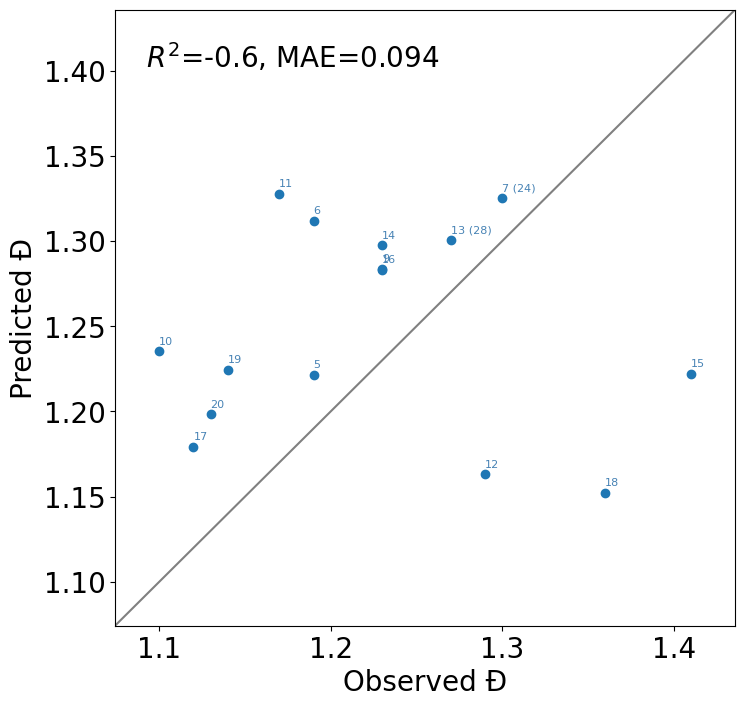

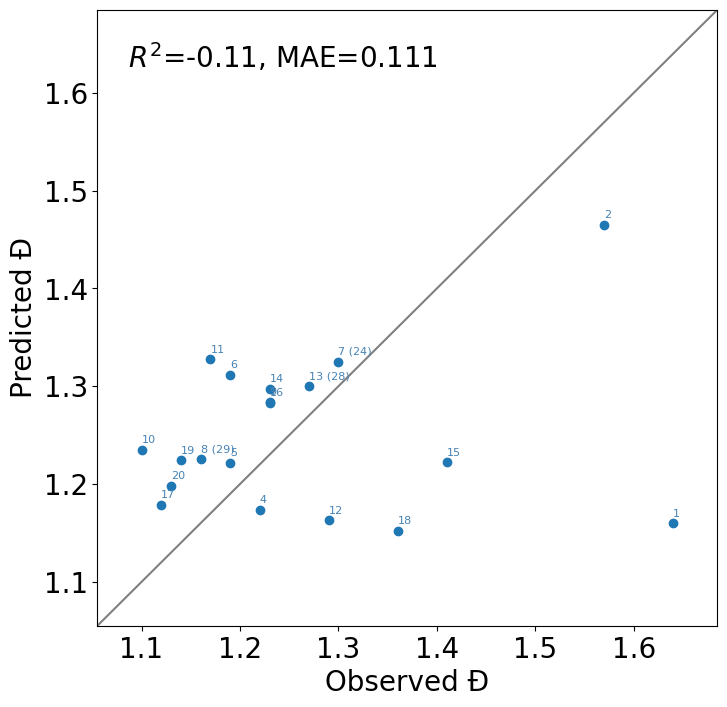

In [25]:
if __name__ == "__main__":
    # file & preprocessing
    try:     
        df_X = pd.read_excel("../data/XY/data_set_{}/data_set_{}_{}_descriptors.xlsx".format(data_set, data_set, descriptors), index_col = 0, sheet_name = monomer) #descriptors select
    except ValueError:
        print(f"Sheet '{monomer}' not found. Loading the first sheet instead.")
        df_X = pd.read_excel("../data/XY/data_set_{}/data_set_{}_{}_descriptors.xlsx".format(data_set, data_set, descriptors), index_col = 0)
        
    df_Y = pd.read_excel("../data/XY/data_set_{}/data_set_{}_SMILES&objective_function.xlsx".format(data_set, data_set), index_col = 0)
    
#     df_X.drop(["Conversion"], axis=1, inplace=True) 
    df = pd.concat([df_X, df_Y], axis=1)

    
    df.index = df.index.astype("str")
    X = df.iloc[:, :len(df_X.columns)]
    print(X)
    y = np.log(df["{}_PDI".format(monomer)]-1) # St_PDI or nBA_PDI
    
    fold = len(df.index)
    kf = KFold(n_splits=fold, shuffle=True, random_state=rseed_cv)
    kf_inner = KFold(n_splits=fold-1, shuffle=True, random_state=rseed_cv_inner)
    
    model_3sigma = ARDRegression(n_iter=1000)
    model_T2 = ARDRegression(n_iter=1000)
    model_3NN = ARDRegression(n_iter=1000)
    
    dirname = "../result/AD"
    os.makedirs(dirname, exist_ok = True)
    
    
    df_AD = pd.DataFrame(index = X.index, columns = ["observed_PDI", "predicted_PDI_3sigma", "3sigma_All", "3sigma_Sel","predicted_PDI_T2","T2_All", "T2_Sel","predicted_PDI_3-NN","3-NN_All", "3-NN_Sel"])
    for ifold, (tridx, tsidx) in enumerate(kf.split(X, y)):
        Xtr, Xts = X.iloc[tridx], X.iloc[tsidx]
        ytr, yts = y.iloc[tridx], y.iloc[tsidx]
        
        
        out_of_range_indices_3sigma = []
        out_of_range_indices_knn = []
        out_of_range_indices_T2 = []
        
        for jfold, (tridx, tsidx) in enumerate(kf_inner.split(Xtr, ytr)):
            
            Xtr_inner, Xts_inner = Xtr.iloc[tridx], Xtr.iloc[tsidx]
            ytr_inner, yts_inner = ytr.iloc[tridx], ytr.iloc[tsidx]
        
            #scaling
            scaler_X_inner = StandardScaler()
            scaler_X_inner.fit(Xtr_inner)
            Xtr_sc = pd.DataFrame(scaler_X_inner.transform(Xtr_inner), index = Xtr_inner.index, columns = Xtr_inner.columns)
            Xts_sc = pd.DataFrame(scaler_X_inner.transform(Xts_inner), index = Xts_inner.index, columns = Xts_inner.columns)
            
            
            #3sigma
            out_of_range_indices_3sigma.extend(Xts_sc.index[(Xts_sc.abs() > 3).any(axis=1)].tolist())
        
            
            #T2_value
            T2_test, T2_train_max, df_contri, kiyo = T2_value(Xtr_sc, Xts_sc, 6)
            inside_ad_flag_T2_train = T2_test<=T2_train_max
            outside_ad_indices_fold = Xts_inner[~inside_ad_flag_T2_train].index.tolist()
            out_of_range_indices_T2.extend(outside_ad_indices_fold)
            
            
            #3-NN
            mean_knn_distance_test, ad_threshold = knn(3, 1, Xtr_sc, Xts_sc)
            inside_ad_flag_train = mean_knn_distance_test <= ad_threshold
            outside_ad_indices_fold = Xts_inner[~inside_ad_flag_train].index.tolist()
            out_of_range_indices_knn.extend(outside_ad_indices_fold)
            

        #selected sample
        Xtr_3sigma = Xtr.loc[~Xtr.index.isin(out_of_range_indices_3sigma)]
        Xtr_knn = Xtr.loc[~Xtr.index.isin(out_of_range_indices_knn)]
        Xtr_T2 = Xtr.loc[~Xtr.index.isin(out_of_range_indices_T2)]
           
        ytr_3sigma = ytr.loc[~ytr.index.isin(out_of_range_indices_3sigma)]
        ytr_knn = ytr.loc[~ytr.index.isin(out_of_range_indices_knn)]
        ytr_T2 = ytr.loc[~ytr.index.isin(out_of_range_indices_T2)]
        
        #scaling
        scaler_X_3sigma = StandardScaler()
        scaler_X_3sigma.fit(Xtr_3sigma)
        Xtr_3sigma_sc = pd.DataFrame(scaler_X_3sigma.transform(Xtr_3sigma), index = Xtr_3sigma.index, columns = Xtr_3sigma.columns)
        Xts_3sigma_sc = pd.DataFrame(scaler_X_3sigma.transform(Xts), index = Xts.index, columns = Xts.columns)
        
        scaler_X_T2 = StandardScaler()
        scaler_X_T2.fit(Xtr_T2)
        Xtr_T2_sc = pd.DataFrame(scaler_X_T2.transform(Xtr_T2), index = Xtr_T2.index, columns = Xtr_T2.columns)
        Xts_T2_sc = pd.DataFrame(scaler_X_T2.transform(Xts), index = Xts.index, columns = Xts.columns)
            
        scaler_X_knn = StandardScaler()
        scaler_X_knn.fit(Xtr_knn)
        Xtr_knn_sc = pd.DataFrame(scaler_X_knn.transform(Xtr_knn), index = Xtr_knn.index, columns = Xtr_knn.columns)
        Xts_knn_sc = pd.DataFrame(scaler_X_knn.transform(Xts), index = Xts.index, columns = Xts.columns)
        
       
        #All
        #3sigma
        df_AD.loc[Xts_3sigma_sc.index, "3sigma_All"] = ~(np.abs(Xts_3sigma_sc) > 3).any(axis=1)
    
        
        #T2_value
        T2_test, T2_train_max, df_contri, kiyo = T2_value(Xtr_T2_sc, Xts_T2_sc, 6)
        df_AD.loc[Xts_T2_sc.index, "T2_All"] = T2_test<=T2_train_max
        
        
        #3-NN
        mean_of_knn_distance_pre, ad_threshold = knn(3, 1, Xtr_knn_sc, Xts_knn_sc)
        df_AD.loc[Xts_knn_sc.index, "3-NN_All"] = mean_of_knn_distance_pre<= ad_threshold
        
        #Sel
        Xtr_3sigma_sel, Xts_3sigma_sel = search_highly_correlated_variables_cv(Xtr_3sigma_sc, Xts_3sigma_sc, 0.8)
        Xtr_T2_sel, Xts_T2_sel = search_highly_correlated_variables_cv(Xtr_T2_sc, Xts_T2_sc, 0.8)
        Xtr_knn_sel, Xts_knn_sel = search_highly_correlated_variables_cv(Xtr_knn_sc, Xts_knn_sc, 0.8)
        
        Xtr_3sigma_sel, Xts_3sigma_sel = boruta_cv(Xtr_3sigma_sel, ytr_3sigma, Xts_3sigma_sel, perc = perc, rseed_boruta = rseed_boruta) # select the best perc 
        Xtr_T2_sel, Xts_T2_sel = boruta_cv(Xtr_T2_sel, ytr_T2, Xts_T2_sel, perc = perc, rseed_boruta = rseed_boruta) # select the best perc 
        Xtr_knn_sel, Xts_knn_sel = boruta_cv(Xtr_knn_sel, ytr_knn, Xts_knn_sel, perc = perc, rseed_boruta = rseed_boruta) # select the best perc 
        
        print(Xts_3sigma_sel)
        #3sigma
        df_AD.loc[Xts_3sigma_sel.index, "3sigma_Sel"] = ~(np.abs(Xts_3sigma_sel) > 3).any(axis=1)
    
        
        #T2_value St:Comment out for styrene
        T2_test, T2_train_max, df_contri, kiyo = T2_value(Xtr_T2_sel, Xts_T2_sel, 6)
        df_AD.loc[Xts_T2_sel.index, "T2_Sel"] = T2_test<=T2_train_max
        
        
        #3-NN
        mean_of_knn_distance_pre, ad_threshold = knn(3, 1, Xtr_knn_sel, Xts_knn_sel)
        df_AD.loc[Xts_knn_sel.index, "3-NN_Sel"] = mean_of_knn_distance_pre<= ad_threshold
        
        
        #predict
        model_3sigma.fit(Xtr_3sigma_sel, ytr_3sigma)
        ytr_pred_3sigma = model_3sigma.predict(Xtr_3sigma_sel)
        yts_pred_3sigma = model_3sigma.predict(Xts_3sigma_sel)  
        
        #St:Comment out for styrene
        model_T2.fit(Xtr_T2_sel, ytr_T2)
        ytr_pred_T2 = model_T2.predict(Xtr_T2_sel)
        yts_pred_T2 = model_T2.predict(Xts_T2_sel) 
        
        model_3NN.fit(Xtr_knn_sel, ytr_knn)
        ytr_pred_3NN = model_3NN.predict(Xtr_knn_sel)
        yts_pred_3NN = model_3NN.predict(Xts_knn_sel) 
        
        df_AD.loc[Xts.index, 'predicted_PDI_3sigma'] = np.exp(yts_pred_3sigma) + 1
        df_AD.loc[Xts.index, 'predicted_PDI_T2'] = np.exp(yts_pred_T2) + 1
        df_AD.loc[Xts.index, 'predicted_PDI_3-NN'] = np.exp(yts_pred_3NN) + 1
        df_AD.loc[Xts.index, 'observed_PDI'] = np.exp(yts) + 1    

    df_AD.to_excel(dirname + "./AD_after_removing_{}_{}.xlsx".format(monomer, descriptors))
    
    print(df_AD)
 
    for l in ["3sigma"]:  #"3sigma", "T2", "3-NN"
        
        all_index = df_AD[df_AD['{}_All'.format(l)] == True].index
        sel_index = df_AD[df_AD['{}_Sel'.format(l)] == True].index
        
        #all
        r2 = r2_score(df_AD.loc[all_index, 'observed_PDI'], df_AD.loc[all_index, 'predicted_PDI_{}'.format(l)])
        MAE = mean_absolute_error(df_AD.loc[all_index, 'observed_PDI'], df_AD.loc[all_index, 'predicted_PDI_{}'.format(l)])

        #yy-plot
        yyplot_k(df_AD.loc[all_index, 'observed_PDI'], df_AD.loc[all_index, 'predicted_PDI_{}'.format(l)])

        for i, label in enumerate (df_AD.loc[all_index].index):
            plt.annotate(label, xy = (df_AD['observed_PDI'][label], df_AD['predicted_PDI_{}'.format(l)][label]), xytext=(0, 5),  # Adjust these values as needed
                textcoords='offset points',size =8, color = "steelblue")
            
        plt.text(0.05, 0.95, r"$R^2$={}, MAE={}".format(round(r2, 2), round(MAE, 3)), transform=plt.gca().transAxes,
                  verticalalignment='top', horizontalalignment='left',
                  bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))


        plt.savefig(dirname + "/AD_{}_All_{}.jpg".format(l, monomer))
    
    
    for l in ["3sigma"]:
        
        #sel
        r2 = r2_score(df_AD.loc[sel_index, 'observed_PDI'], df_AD.loc[sel_index, 'predicted_PDI_{}'.format(l)])
        MAE = mean_absolute_error(df_AD.loc[sel_index, 'observed_PDI'], df_AD.loc[sel_index, 'predicted_PDI_{}'.format(l)])

        #yy-plot
        yyplot_k(df_AD.loc[sel_index, 'observed_PDI'], df_AD.loc[sel_index, 'predicted_PDI_{}'.format(l)])

        for i, label in enumerate (df_AD.loc[sel_index].index):
            plt.annotate(label, xy = (df_AD['observed_PDI'][label], df_AD['predicted_PDI_{}'.format(l)][label]), xytext=(0, 5),  # Adjust these values as needed
                textcoords='offset points',size =8, color = "steelblue")
            
        plt.text(0.05, 0.95, r"$R^2$={}, MAE={}".format(round(r2, 2), round(MAE, 3)), transform=plt.gca().transAxes,
                  verticalalignment='top', horizontalalignment='left',
                  bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))


        plt.savefig(dirname + "/AD_{}_Sel_{}.jpg".format(l, monomer))